In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [2]:
# Check dataset structure
img_path = 'data/Images/0199_1_001_029.tif'
label_path = 'data/Labels/0199_1_001_029.tif'

img = np.array(Image.open(img_path))
label = np.array(Image.open(label_path))

print('Image shape:', img.shape)
print('Image dtype:', img.dtype)
print('Label shape:', label.shape)
print('Label dtype:', label.dtype)
print('Unique label values:', np.unique(label))

Image shape: (256, 256, 3)
Image dtype: uint8
Label shape: (256, 256, 3)
Label dtype: uint8
Unique label values: [  0 127 255]


In [3]:
# Define color map for different land types
COLOR_MAP = {
    "UN": [173, 34, 34],      # Dark red
    "PA": [255, 165, 0],      # Orange
    "SH": [255, 255, 0],      # Yellow
    "FO": [0, 128, 0],        # Dark green
    "BU": [0, 255, 0],        # Lime green
    "AR": [144, 238, 144],    # Light green
    "GR": [255, 0, 255],      # Magenta
    "RO": [0, 255, 255],      # Cyan
    "WA": [0, 0, 255],        # Blue
    "FR": [0, 0, 139],        # Dark blue
    "VI": [128, 0, 128],      # Purple
    "OT": [0, 0, 0],          # Black (non-defined land)
}

In [4]:
def draw_segmentation(image_path, label_path, selected_classes=None, alpha=0.5):
    """
    Draw segmentation overlay on image.
    
    Args:
        image_path: Path to the image file
        label_path: Path to the label file
        selected_classes: List of class names to visualize (None = all classes)
                         Example: ["FO", "BU", "WA"] or None
        alpha: Transparency of overlay (0=transparent, 1=opaque)
    """
    img = np.array(Image.open(image_path))
    label = np.array(Image.open(label_path))
    
    # If label is 3D (RGB), take only first channel
    if len(label.shape) == 3:
        label = label[:, :, 0]
    
    # Convert grayscale to RGB if needed
    if len(img.shape) == 2:
        img = np.stack([img, img, img], axis=-1)
    
    # Create colored segmentation mask
    colored_mask = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    
    class_names = list(COLOR_MAP.keys())
    for class_id, class_name in enumerate(class_names):
        if selected_classes is None or class_name in selected_classes:
            mask = (label == class_id)
            colored_mask[mask] = COLOR_MAP[class_name]
    
    # Blend image with segmentation
    blended = img.copy()
    mask_pixels = np.any(colored_mask > 0, axis=-1)
    blended[mask_pixels] = (alpha * colored_mask[mask_pixels] + (1 - alpha) * img[mask_pixels]).astype(np.uint8)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(colored_mask)
    axes[1].set_title('Segmentation Mask')
    axes[1].axis('off')
    
    axes[2].imshow(blended)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print class information
    unique_ids = np.unique(label)
    unique_names = [class_names[i] for i in unique_ids if i < len(class_names)]
    print(f'Classes in this image: {unique_names}')

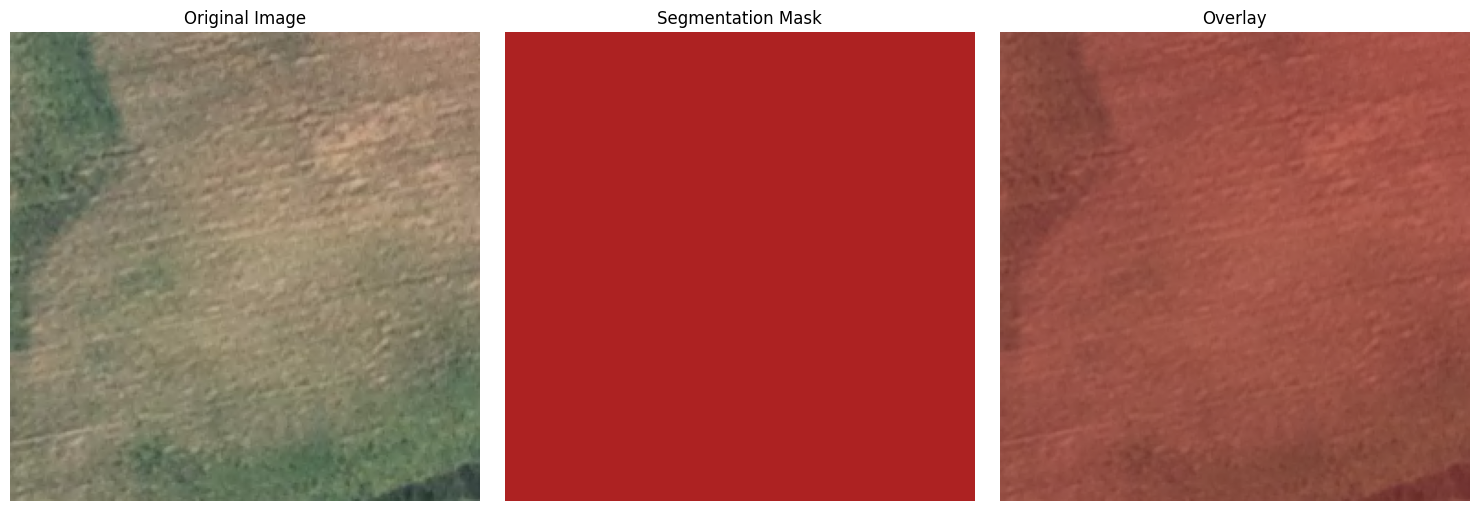

Classes in this image: ['UN']


In [5]:
# Example: Visualize all classes
draw_segmentation(
    'data/Images/0199_1_001_029.tif',
    'data/Labels/0199_1_001_029.tif',
    selected_classes=None,  # Show all classes
    alpha=0.5
)

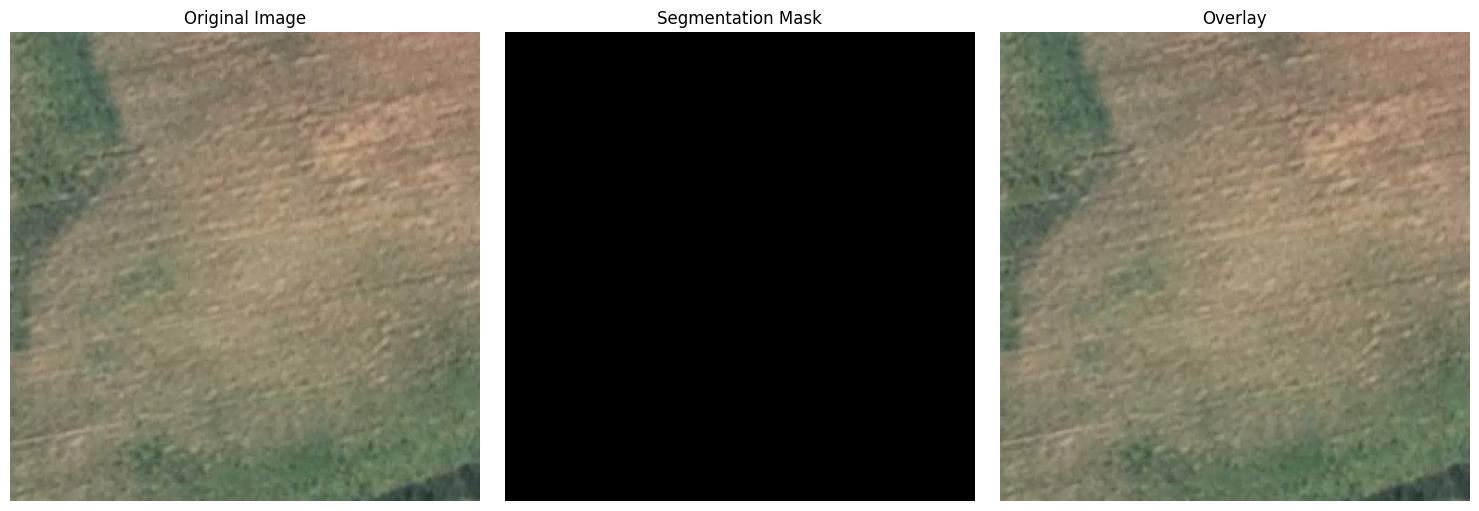

Classes in this image: ['UN']


In [6]:
# Example: Visualize only specific classes (e.g., forests and buildings)
draw_segmentation(
    'data/Images/0199_1_001_029.tif',
    'data/Labels/0199_1_001_029.tif',
    selected_classes=["FO", "BU"],  # Forest and Buildings
    alpha=0.6
)

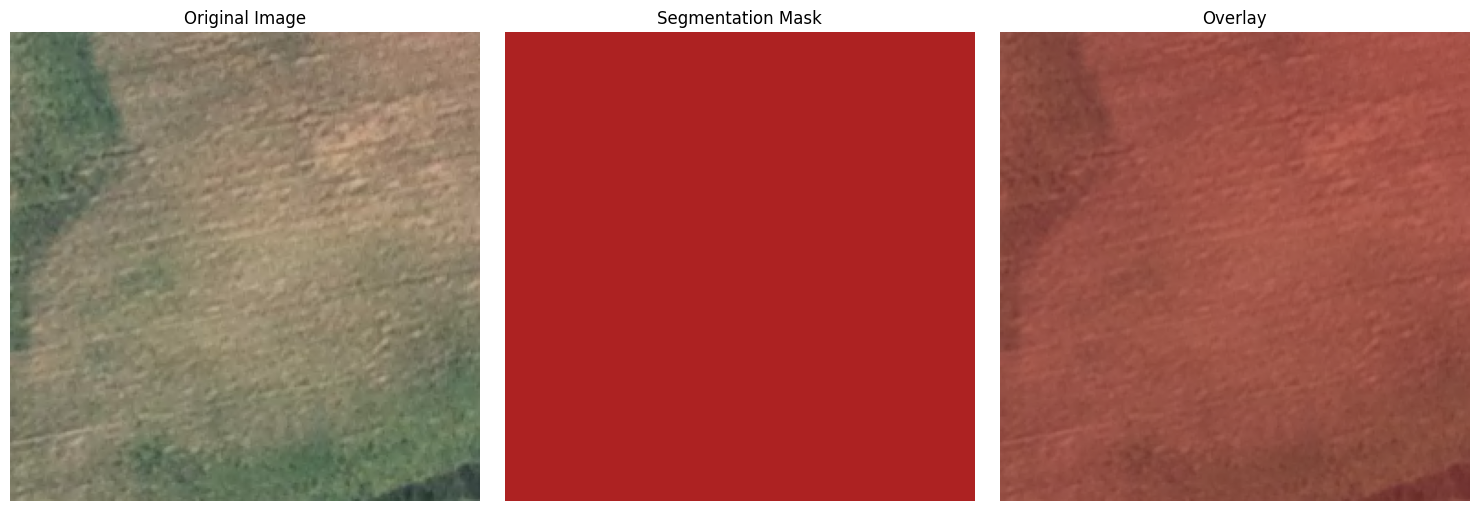

Classes in this image: ['UN']


In [ ]:
# Interactive: Choose your own image and classes
image_name = '0199_1_001_029.tif'  # Change this
classes_to_show = None  

draw_segmentation(
    f'data/Images/{image_name}',
    f'data/Labels/{image_name}',
    selected_classes=classes_to_show
)